# Greek Protipa Exams Dataset: EDA & Samples

This notebook demonstrates how to load the **Greek Protipa Exams** dataset from Hugging Face, inspect samples, and perform Exploratory Data Analysis (EDA) using specialized utility functions.

In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from dotenv import load_dotenv, find_dotenv
import numpy as np

from protipa_exams_dataset.eda_utils import (
    print_sample, 
    display_samples,
    display_multimodal_samples, 
    plot_subject_dist,      # New (separated)
    plot_level_dist,        # New (separated)
    plot_format_dist,       # New (separated)
    plot_reference_dist,     # New (separated)
    plot_temporal_distribution,
    plot_points_distribution
)

# Load environment variables
load_dotenv(find_dotenv())

repo_id = os.getenv("HF_REPO_ID")
token = os.getenv("HF_TOKEN")

print(f"Using Repository: {repo_id}")



Using Repository: pprokopidis/greek-protipa-exams


## 1. Load the Dataset
We load the `test` split, which contains the consolidated data.

In [36]:
dataset = load_dataset(repo_id, split="test", token=token)
df = dataset.to_pandas()

print(f"✅ Dataset loaded. Total rows: {len(df)}")

README.md:   0%|          | 0.00/955 [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1646 [00:00<?, ? examples/s]

✅ Dataset loaded. Total rows: 1646


## 2. Inspect Samples
We use the `display_samples` utility to look at a few random questions in detail.


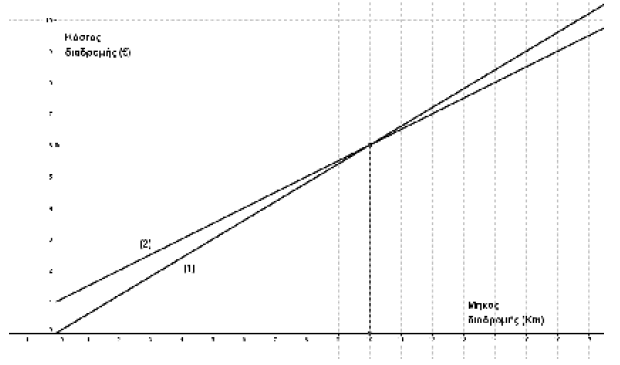

In [38]:
target_id = "math_lyc_2013_2_5.1"
print_sample(df, target_id)
#df[df['id'] == target_id]


In [7]:
display_samples(df, n=3)

id,subject,year,admission_level,question,input,image,choices,answer_text,answer_index
math_lyc_2022_1_31,mathematics,2022,lyceum,Για την ισότητα $1636=43\cdot37+45$ είναι αλήθεια ότι:,,,• Α. αντιστοιχεί σε Ευκλείδεια Διαίρεση με διαιρετέο 1636 και υπόλοιπο 45.• Β. αντιστοιχεί σε Ευκλείδεια Διαίρεση με διαιρέτη το 43.• Γ. αντιστοιχεί σε Ευκλείδεια Διαίρεση με πηλίκο το 43.• Δ. δεν αντιστοιχεί σε Ευκλείδεια Διαίρεση.,Δ,3
greek_language_lyc_2025_2_7,greek_language,2025,lyceum,Στη φράση «μεθυσμένοι από τις τεχνολογικές επιτυχίες» εντοπίζεται το παρακάτω σχήμα λόγου:,"Κείμενο Α: Η Ανθρωπότητα Χωρίς Πυξίδα (ΙΙ) Η εξέλιξη των κοινωνιών του δυτικού κόσμου, από την έναρξη της βιομηχανικής επανάστασης και μετά, βασίστηκε στην αφελή ιδέα ότι όσο περισσότερα υλικά αγαθά έχουμε τόσο καλύτερα θα ζούμε και τόσο πιο ευτυχείς θα είμαστε. Οι μακροχρόνιες συνέπειες αυτής της αντίληψης, που κυριάρχησε σε ολόκληρο τον κόσμο, και των τεχνολογικών εξελίξεων, που κατέστησαν δυνατή την εκπληκτική οικονομική ανάπτυξη, είναι η σπάταλη υπερκατανάλωση υλικών αγαθών και η εκρηκτική αύξηση του παγκόσμιου πληθυσμού. Αν αναζητείτε τους ενόχους για την άθλια κατάσταση του περιβάλλοντος του πλανήτη μας, αυτοί είναι, σε πρώτο επίπεδο, η υπερκατανάλωση και ο υπερπληθυσμός. Ο κυρίαρχος τρόπος ζωής βασίζεται στην προσπάθεια να αποκτήσουμε περισσότερα και καλύτερα υλικά αντικείμενα (σπίτια, έπιπλα, ρούχα, αυτοκίνητα κ.τ.λ.) και παράλληλα περισσότερα παιδιά. Μετά τον Β΄ Παγκόσμιο Πόλεμο, το πρότυπο αυτό υιοθετήθηκε σε όλον τον πλανήτη. [...] Η εξέλιξη αυτή είναι αποτέλεσμα ενός βασικού λάθους. Οι άνθρωποι συνέχιζαν να επιδιώκουν μανιωδώς την υλική ευημερία τους και τη συνακόλουθη, όπως νόμιζαν, ευτυχία τους χωρίς προηγουμένως να θέσουν το βασικό σωκρατικό ερώτημα του «πώς πρέπει να ζω;». Εκτός, βέβαια, αν κάποιος θέλει να υποστηρίξει ότι ο τρόπος ζωής που ακολούθησε η ανθρωπότητα είναι ακριβώς η απάντηση στο ερώτημα αυτό. Αν αυτό είναι σωστό, τότε ας είναι οι άνθρωποι προετοιμασμένοι να υποστούν τις συνέπειες των επιλογών τους και το μόνο που μπορούμε να κάνουμε είναι να εκφράσουμε τη λύπη μας γι' αυτούς που ενώ επέλεξαν έναν μετρημένο τρόπο ζωής υποφέρουν από την ασυδοσία και την απληστία των πολλών. Δυστυχώς, η κρισιμότητα της παρούσας κατάστασης του περιβάλλοντος μας επιβάλλει να σκεφτούμε και να αποφασίσουμε για το πώς θέλουμε να ζούμε. Και επειδή οι παράγοντες που μας έφεραν στο κατώφλι της καταστροφής είναι δύο, δηλαδή η υπερκατανάλωση και ο υπερπληθυσμός, οι επιλογές μας περιορίζονται σε τρεις: δραστική μείωση της κατανάλωσης ώστε να μπορεί να συντηρηθεί ο παρών πληθυσμός ή δραστική μείωση του πληθυσμού ώστε να διατηρηθεί το παρόν επίπεδο κατανάλωσης ή μείωση και των δύο σε μικρότερο βαθμό. Οι μειώσεις αυτές πρέπει να είναι αρκετές ώστε να αποκατασταθεί η οικολογική ισορροπία του πλανήτη. Με άλλα λόγια, οι επιλογές μας είναι περιορισμένες. Μπορούμε να είμαστε πολλοί και να ζούμε άθλια από πολλές απόψεις ή να είμαστε λίγοι και να ζούμε με άνεση και αξιοπρέπεια. [...] Αποτελεί τραγική ειρωνεία το ότι το ερώτημα του πώς πρέπει να ζούμε είχε τεθεί και απαντηθεί από τους αρχαίους Έλληνες, κυρίως από τον Πλάτωνα στους Νόμους και από τον Αριστοτέλη στα Πολιτικά, αλλά οι νεότεροι, πιθανότατα **μεθυσμένοι από τις τεχνολογικές επιτυχίες**, είτε τους αγνόησαν ή δεν τους κατάλαβαν. Οι σοφοί αυτοί άνδρες προτείνουν άνετη, αλλά όχι σπάταλη ζωή, και ισορροπία μεταξύ πληθυσμού και διαθεσίμων πόρων.",,• Α. μεταφορά• Β. μετωνυμία• Γ. προσωποποίηση• Δ. παρομοίωση,A,0
greek_language_gym_2021_6_3,greek_language,2021,gymnasium,Η φράση «επί τούτου» σημαίνει,"Κείμενο: «Φως στα μυστήρια της προϊστορικής Κέρου» Πάει πολύς καιρός αφότου έκανα ελεύθερη κατασκήνωση στα Κουφονήσια, θυμάμαι όμως άριστα πόσο μας εξίταρε ο ευμεγέθης βράχος που ορθωνόταν μέσα από τη θάλασσα απέναντί μας. Ήταν η μυστηριώδης νήσος Κέρος, μόνιμο σκηνικό στο βάθος του ορίζοντα που μας δημιουργούσε δέος στο άκουσμα διάφορων ιστοριών και θρύλων για τα πλήθος αρχαία που βρίσκονταν θαμμένα εκεί αλλά και τους αρχαιοκάπ

## 3. Multimodal Analysis (Samples with Images)
Let's specifically look at questions that include visual aids. We display them as a DataFrame first, then show the images.

id,subject,year,admission_level,question,input,image,choices,answer_text,answer_index
greek_language_lyc_2013_1_2,greek_language,2013,lyceum,Το κείμενο 2 είναι η αφίσα της ευρωπαϊκής εκστρατείας κατά του σχολικού εκφοβισμού. Ποιο νομίζεις ότι είναι το θέμα της αφίσας και σε ποιους απευθύνεται το μήνυμα; Να αιτιολογήσεις την απάντησή σου .,,,,"Η αφίσα έχει θέμα τη στάση των μαθητών – θεατών απέναντι σε περιστατικά σχολικής βίας. Στην αφίσα εικονίζεται ένας έφηβος μαθητής που καλύπτει το πρόσωπό του με τετράδια, ενώ είναι κουλουριασμένος και μάλλον στριμωγμένος σ’ έναν τοίχο. Στη φωτογραφία σε πρώτο πλάνο φαίνεται η σφιγμένη γροθιά ενός άλλου αγοριού. Στην πάνω πλευρά της αφίσας αναγράφεται το μήνυμα με κεφαλαία γράμματα διαφορετικών χρωμάτων και κλιμακούμενου μεγέθους «ΕΣΥ ΠΟΥ ΤΑ ΒΛΕΠΕΙΣ ΚΑΝΕ ΤΗ ΔΙΑΦΟΡΑ ΜΙΛΑ ΤΩΡΑ! ΣΤΟ ΔΑΣΚΑΛΟ ΣΟΥ ΣΤΟ ΓΟΝΙΟ ΣΟΥ.». Το β΄ ενικό πρόσωπο σε συνδυασμό με την προστακτική έγκλιση και το θαυμαστικό δείχνουν ότι το μήνυμα απευθύνεται με αμεσότητα στους μαθητές – θεατές που δεν αντιδρούν σε περιστατικά σχολικής βίας και τους προτρέπει να κάνουν τη διαφορά και να μιλήσουν. Στην κάτω πλευρά της αφίσας αναγράφονται οι φορείς που φαίνεται ότι πραγματοποιούν αυτή την εκστρατεία, προκειμένου να ευαισθητοποιήσουν τους νεαρούς μαθητές.",
math_gym_2016_1_3,mathematics,2016,gymnasium,"Ο πλανήτης Π έχει 3 δορυφόρους. Ο δορυφόρος Γ κάνει μια πλήρη περιστροφή γύρω από τον πλανήτη σε 3 ημέρες, ο Δ σε 4 ημέρες και ο Ε σε 5 ημέρες. Πριν από 2 ημέρες οι δορυφόροι βρέθηκαν στη θέση που φαίνεται στο παραπάνω σχέδιο. Μετά από πόσες ημέρες θα βρεθούν και πάλι στην ίδια θέση;",,,• Α. 10• Β. 12• Γ. 25• Δ. 58• Ε. 60,Δ,3
math_lyc_2013_2_5.1,mathematics,2013,lyceum,"Δύο εταιρείες ταξί έχουν τις ακόλουθες χρεώσεις: Η εταιρεία ταξί «Αθήνα» χρεώνει 1€ για τη σημαία και 0,5€ ανά km διανυόμενης διαδρομής. Η εταιρεία ταξί «Βιαστικός» (για να προσελκύσει πελάτες) δε χρεώνει σημαία, αλλά μόνο το κόστος διαδρομής, που είναι 0,6€ ανά km διανυόμενης διαδρομής.Ποιο διάγραμμα (1) ή (2) ταιριάζει στην κάθε εταιρεία;| Εταιρεία | Διάγραμμα || :---: | :---: || «Αθήνα» | || «Βιαστικός» | |",,,,"""Η σωστή συμπλήρωση του πίνακα δίνει:",

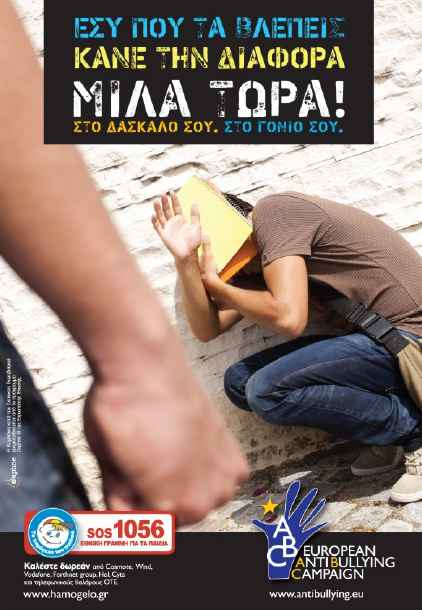
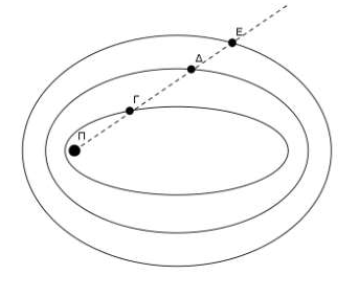
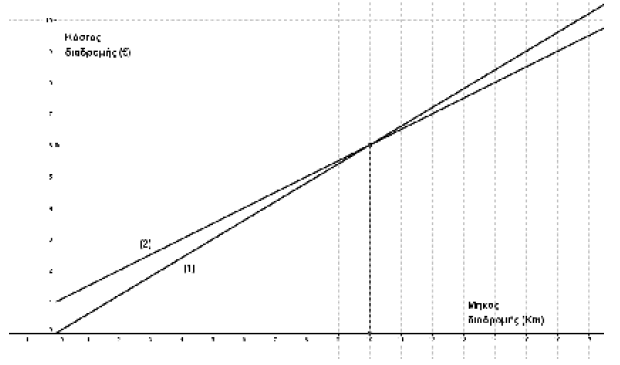

In [26]:
display_samples(df, n=3, prioritize_images=True)

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution by Subject and Admission Level

,Subject,Count
0,greek_language,833
1,mathematics,714
2,religious studies,90
3,physics,9


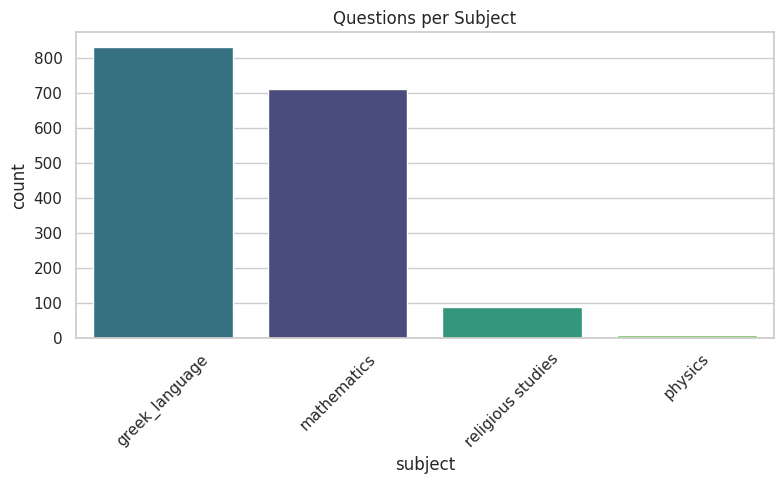

In [9]:

# Subject Distribution
fig_subj, df_subj = plot_subject_dist(df)
display(df_subj)
display(fig_subj)

,Admission Level,Count
0,gymnasium,838
1,lyceum,808


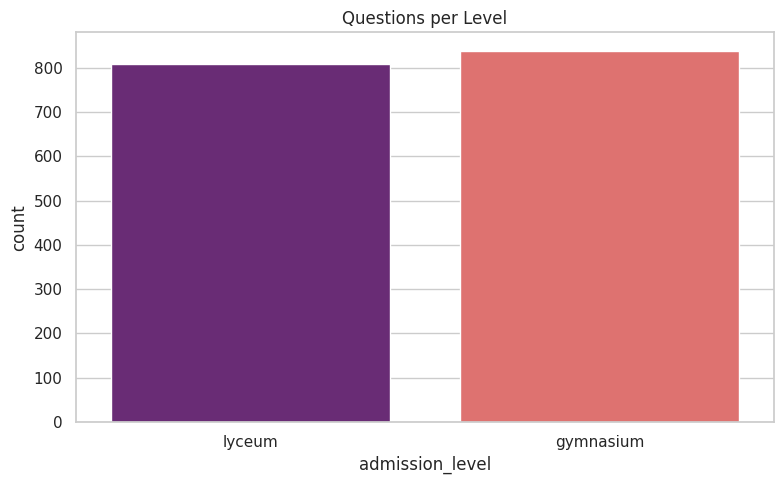

In [10]:
# Admission Level Distribution
fig_level, df_level = plot_level_dist(df)
display(df_level)
display(fig_level)

### 4.2 Distribution by Format and Reference Type

,Format,Count
0,multiple_choice,1268
1,open_ended,222
2,true_false,87
3,fill_in_the_gaps,65
4,matching,4


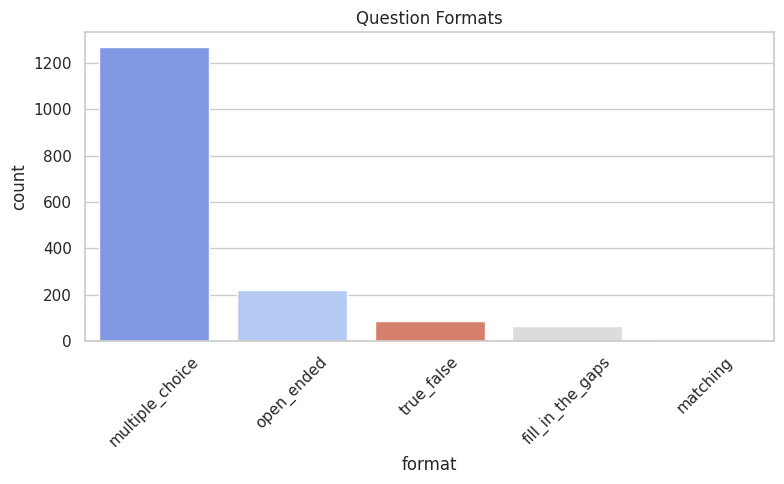

In [11]:
# Question Format Distribution
fig_format, df_format = plot_format_dist(df)
display(df_format)
display(fig_format)

,Reference,Count
0,none,742
1,passage,632
2,multimodal,270
3,table,2


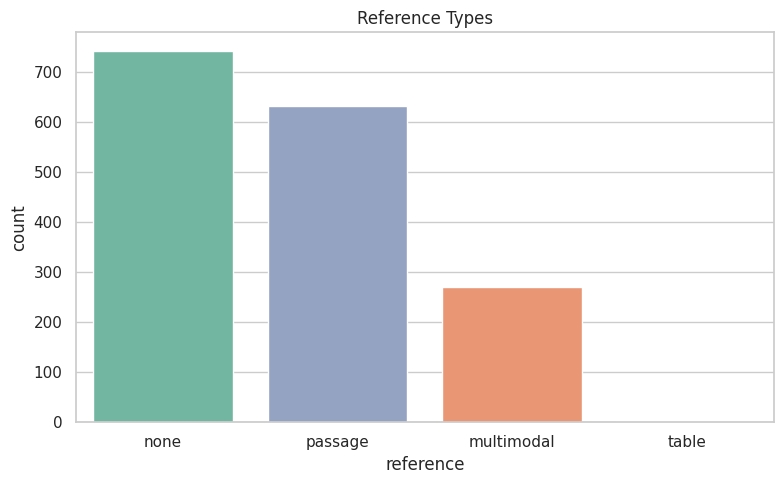

In [12]:
# Reference Type Distribution
fig_ref, df_ref = plot_reference_dist(df)
display(df_ref)
display(fig_ref)

### 4.3 Temporal Trends
How are questions distributed over the years per subject?

subject,greek_language,mathematics,physics,religious studies
year,,,,
2013,80.0,117.0,0.0,0.0
2014,0.0,8.0,9.0,0.0
2016,54.0,51.0,0.0,0.0
2017,65.0,37.0,0.0,0.0
2018,45.0,35.0,0.0,0.0
2019,40.0,24.0,0.0,0.0
2020,206.0,100.0,0.0,0.0
2021,103.0,85.0,0.0,0.0
2022,60.0,65.0,0.0,0.0


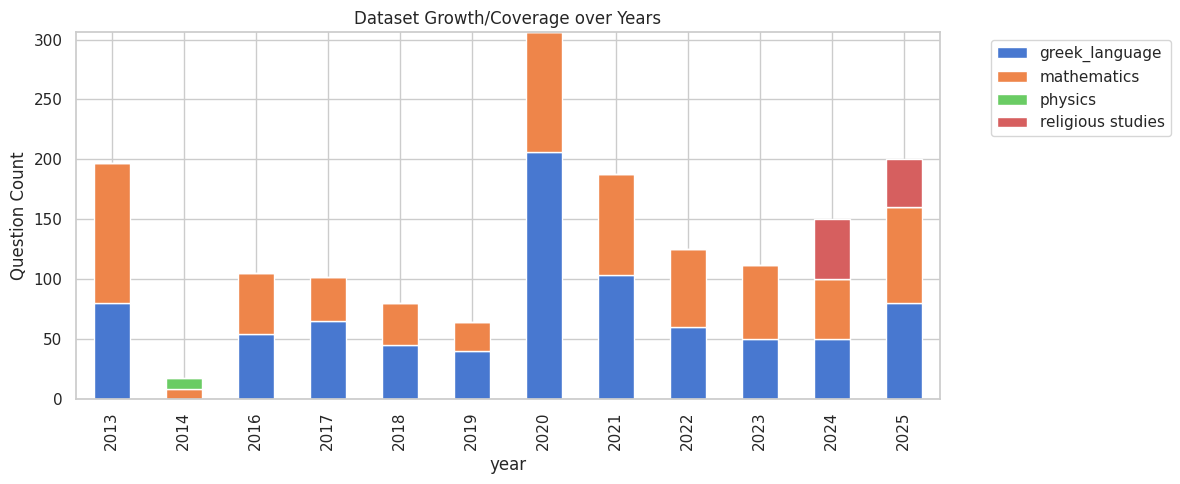

In [13]:
fig_temp, df_temp = plot_temporal_distribution(df)
display(df_temp)
display(fig_temp)

### 4.4 Point Values Analysis

Percentage of questions with point values assigned:
30.62%


,count,mean,std,min,25%,50%,75%,max
points,504.0,3.460317,1.907293,1.0,2.0,3.0,5.0,15.0


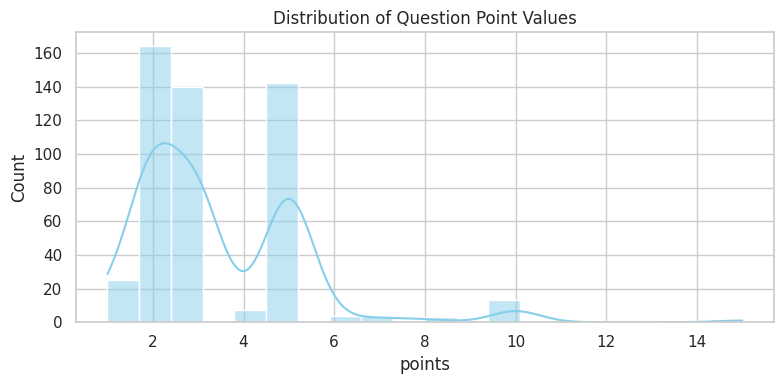

In [14]:
fig_points, df_points = plot_points_distribution(df)
display(df_points)
display(fig_points)

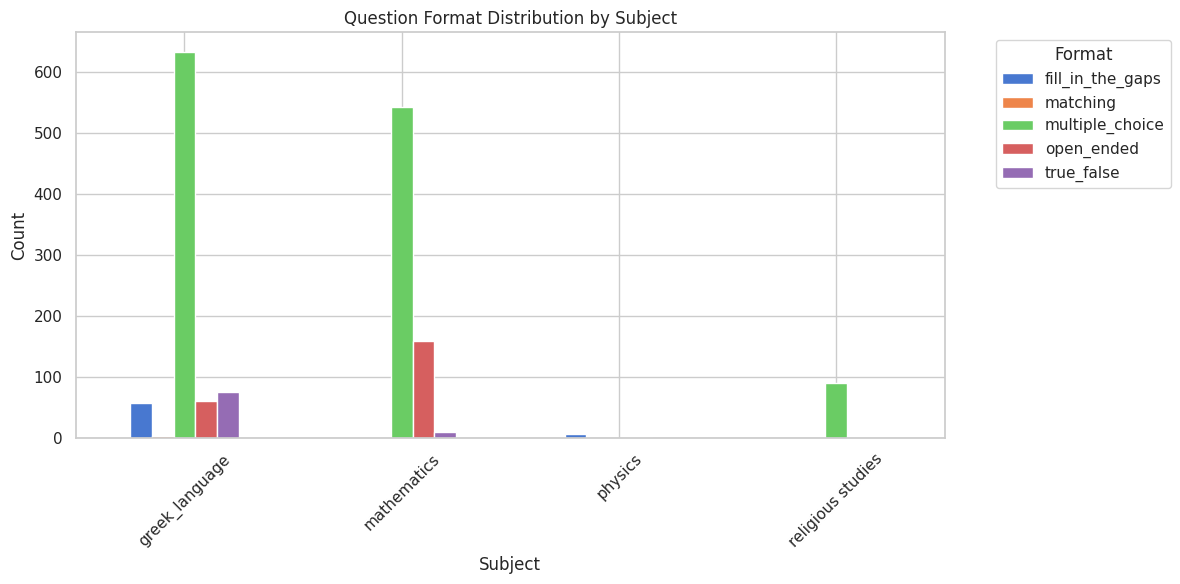

format,fill_in_the_gaps,matching,multiple_choice,open_ended,true_false
subject,,,,,
greek_language,58,4,634,61,76
mathematics,0,0,544,159,11
physics,7,0,0,2,0
religious studies,0,0,90,0,0


In [15]:
from protipa_exams_dataset.eda_utils import plot_format_by_subject
# Returns the matplotlib figure and the pivot table of counts
fig_fmt, df_fmt = plot_format_by_subject(df)
display(fig_fmt)
display(df_fmt)

### 4.5 Unique verification

In [24]:

# Create a temporary series where 'choices' are tuples so they can be hashed/compared
choices_hashable = df['choices'].apply(lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x)

# 1. Total duplicates (Metadata + Choices)
# We find all standard hashable columns and manually include the converted choices
metadata_cols = [col for col in df.columns if df[col].apply(lambda x: not isinstance(x, (list, np.ndarray))).all()]
check_subset = metadata_cols + (['choices'] if 'choices' in df.columns else [])

# We use assign to temporarily hold the hashable choices for the check
total_duplicates = df.assign(choices=choices_hashable).duplicated(subset=check_subset).sum()
print(f"Total duplicate rows (Metadata + Choices): {total_duplicates}")

# 2. Check uniqueness of the 'id' column
if 'id' in df.columns:
    is_id_unique = df['id'].is_unique
    print(f"Is 'id' column unique? {is_id_unique}")
    if not is_id_unique:
        num_duplicates = df.duplicated('id').sum()
        print(f"Number of duplicate IDs: {num_duplicates}")


# 3. Check for rows with identical [Question + Choices + Input]
# This defines a "Semantic Duplicate" (same content, regardless of ID/Year)
subset_to_check = []
if 'question' in df.columns: subset_to_check.append('question')
if 'input' in df.columns:    subset_to_check.append('input')
subset_to_check.append('c_h') # This is our tuple-version of choices

content_duplicates = df.assign(c_h=choices_hashable).duplicated(subset=subset_to_check).sum()

print(f"Rows with identical content ({' + '.join([c if c!='c_h' else 'choices' for c in subset_to_check])}): {content_duplicates}")

# Optional: To actually see them
if content_duplicates > 0:
    print("\nDisplaying samples of content duplicates:")
    dup_rows = df.assign(c_h=choices_hashable)[df.assign(c_h=choices_hashable).duplicated(subset=subset_to_check, keep=False)]
    display(dup_rows.sort_values(by='question')[['id', 'subject', 'year', 'question', 'input']])

# 4. Check for nulls in critical columns
critical_cols = ['id', 'subject', 'admission_level', 'question']
existing_critical = [c for c in critical_cols if c in df.columns]
null_counts = df[existing_critical].isnull().sum()

if null_counts.sum() > 0:
    print("\nNull values in critical columns:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values in critical columns ({', '.join(existing_critical)}).")

Total duplicate rows (Metadata + Choices): 0
Is 'id' column unique? True
Rows with identical content (question + input + choices): 0

✅ No null values in critical columns (id, subject, admission_level, question).


In [25]:
# Filter for duplicate questions
duplicate_questions_df = df[df.duplicated(subset=['question'], keep=False)].sort_values(by='question')

# Display with specific CSS for wrapping and column width
(duplicate_questions_df[['id', 'subject', 'year', 'question']]
 .style.set_properties(**{
     'text-align': 'left',
     'white-space': 'pre-wrap',  # Correctly handles newlines and wrapping
     'max-width': '600px',       # Limits width so it doesn't stretch the screen
     'vertical-align': 'top'
 }))

,id,subject,year,question
229,greek_language_gym_2022_1_3,greek_language,2022,Να βρείτε ποια επιλογή αποτελεί συνώνυμο της λέξης που είναι μαυρισμένη:
230,greek_language_gym_2022_1_4,greek_language,2022,Να βρείτε ποια επιλογή αποτελεί συνώνυμο της λέξης που είναι μαυρισμένη:
100,greek_language_gym_2023_1_14,greek_language,2023,"Ποια από τις παρακάτω προτάσεις αληθεύει, σύμφωνα με το κείμενο;"
1262,greek_language_gym_2021_6_1,greek_language,2021,"Ποια από τις παρακάτω προτάσεις αληθεύει, σύμφωνα με το κείμενο;"
215,greek_language_gym_2022_2_14,greek_language,2022,"Ποια από τις παρακάτω προτάσεις δεν αληθεύει, σύμφωνα με όσα αναφέρονται στο κείμενο;"
216,greek_language_gym_2022_2_15,greek_language,2022,"Ποια από τις παρακάτω προτάσεις δεν αληθεύει, σύμφωνα με όσα αναφέρονται στο κείμενο;"
1410,greek_language_lyc_2020_8_1,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με το νόημα του κειμένου;"
1573,greek_language_gym_2020_10_1,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με το νόημα του κειμένου;"
1586,greek_language_gym_2020_10_14,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με όσα αναφέρονται στο απόσπασμα;"
1587,greek_language_gym_2020_10_15,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με όσα αναφέρονται στο απόσπασμα;"
